# Stage 3 — Baseline Multimodelo
**Objetivo:** Entrenar varios modelos con parámetros default, evaluarlos en el set de validación y elegir el mejor candidato para hiperparametrización con Optuna.

**Regla de oro:** El test set NO se toca hasta haber elegido el modelo final.

## 1. Imports y configuración

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, brier_score_loss, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.svm import SVC, LinearSVC

# Boosting
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

SEED = 2357
print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 2. Carga de datos

In [2]:
DATA = "data/master/"
# ── Ajusta las rutas a tu estructura de carpetas ──
X_TRAIN_PATH = f'{DATA}X_train.csv'
X_VAL_PATH   = f'{DATA}X_val.csv'
X_TEST_PATH  = f'{DATA}X_backtest.csv'
Y_TRAIN_PATH = f'{DATA}y_train.csv'
Y_VAL_PATH   = f'{DATA}y_val.csv'
Y_TEST_PATH  = f'{DATA}y_backtest.csv'
TARGET_COL = 'satisfecho'  # columna objetivo binaria (0/1)

X_train = pd.read_csv(X_TRAIN_PATH)
X_val   = pd.read_csv(X_VAL_PATH)
X_test  = pd.read_csv(X_TEST_PATH)

y_train = pd.read_csv(Y_TRAIN_PATH)
y_val   = pd.read_csv(Y_VAL_PATH)
y_test  = pd.read_csv(Y_TEST_PATH)

print(f'Train:      {X_train.shape}  |  positivos: {y_train.mean().item():.2%}')
print(f'Validación: {X_val.shape}   |  positivos: {y_val.mean().item():.2%}')
print(f'Test:       {X_test.shape}  |  positivos: {y_test.mean().item():.2%}')

Train:      (43294, 25)  |  positivos: 79.36%
Validación: (20374, 25)   |  positivos: 72.69%
Test:       (19590, 25)  |  positivos: 81.58%


In [3]:
print("y_trian:")
print(y_train['satisfecho'].value_counts())

y_trian:
satisfecho
1    34356
0     8938
Name: count, dtype: int64


## 3. Definición de modelos

Todos con `random_state=SEED` para reproducibilidad. Parámetros default salvo donde se necesita activar `predict_proba` explícitamente.

In [ ]:
modelos = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        random_state=SEED, n_jobs=-2
    ),
    'CatBoost': CatBoostClassifier(
        random_state=SEED, verbose=False, devices='0-4'
    ),
    'LightGBM': LGBMClassifier(
        random_state=SEED, verbosity=-1, n_jobs=-2
    ),
#    'SVM': SVC(
#        random_state=SEED, probability=True
#    ),    
    'linearSVM': LinearSVC(
        random_state=SEED
    ),
    'ExtraTreeC': ExtraTreesClassifier(
        n_estimators=500, random_state=SEED, n_jobs=-2
    ),
    'SGD': SGDClassifier(
        loss='log_loss', random_state=SEED
    ),
    'HGBC': HistGradientBoostingClassifier(
        random_state=SEED
    ),
}

print(f'{len(modelos)} modelos definidos ✓')

8 modelos definidos ✓


## 4. Entrenamiento y evaluación en validación

In [ ]:
def evaluar(nombre, modelo, X_tr, y_tr, X_v, y_v):
    """Entrena el modelo y devuelve un dict con todas las métricas."""
    if nombre=='linearSVM':
        modelo = CalibratedClassifierCV(modelo, method='sigmoid')
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_v)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    auc   = roc_auc_score(y_v, proba)
    gini  = 2 * auc - 1
    f1    = f1_score(y_v, pred)
    prec  = precision_score(y_v, pred)
    rec   = recall_score(y_v, pred)
    brier = brier_score_loss(y_v, proba)   # menor es mejor

    return {
        'Modelo'    : nombre,
        'AUC-ROC'   : round(auc,  4),
        'Gini'      : round(gini, 4),
        'F1'        : round(f1,   4),
        'Precision' : round(prec, 4),
        'Recall'    : round(rec,  4),
        'Brier↓'    : round(brier,4),
        '_proba'    : proba,           # guardamos para las curvas ROC
        '_modelo'   : modelo,
    }

resultados = []
import time
for nombre, modelo in modelos.items():
    t0 = time.time()
    print(f'Entrenando {nombre}...', end=' ')
    r = evaluar(nombre, modelo, X_train, y_train, X_val, y_val)
    resultados.append(r)
    tf = time.time() - t0
    print(f'AUC={r["AUC-ROC"]} | Gini={r["Gini"]} | F1={r["F1"]} | Time={tf:.3f} s')

print('\n✓ Entrenamiento completo')

Entrenando Logistic Regression... AUC=0.7636 | Gini=0.5271 | F1=0.8762 | Time=0.157 s
Entrenando Random Forest... AUC=0.7491 | Gini=0.4983 | F1=0.8805 | Time=2.498 s
Entrenando CatBoost... AUC=0.7581 | Gini=0.5163 | F1=0.8809 | Time=9.351 s
Entrenando LightGBM... AUC=0.7629 | Gini=0.5258 | F1=0.8814 | Time=0.300 s
Entrenando linearSVM... AUC=0.7634 | Gini=0.5268 | F1=0.8742 | Time=1.318 s
Entrenando ExtraTreeC... AUC=0.7505 | Gini=0.5011 | F1=0.879 | Time=4.680 s
Entrenando SGD... AUC=0.7466 | Gini=0.4933 | F1=0.8746 | Time=0.300 s
Entrenando HGBC... AUC=0.7659 | Gini=0.5318 | F1=0.8811 | Time=0.433 s

✓ Entrenamiento completo


Entrenando SVM... AUC=0.7154 | Gini=0.4308 | F1=0.8797 | Time=1499.867 s

## 5. Tabla comparativa de métricas

In [ ]:
cols_tabla = ['Modelo', 'AUC-ROC', 'Gini', 'F1', 'Precision', 'Recall', 'Brier↓']
df_res = pd.DataFrame(resultados)[cols_tabla].sort_values('AUC-ROC', ascending=False)

def highlight_best(s):
    """Resalta al mejor valor de cada columna métrica."""
    if s.name == 'Brier↓':
        is_best = s == s.min()  # menor es mejor
    elif s.name == 'Modelo':
        return ['' for _ in s]
    else:
        is_best = s == s.max()
    return ['background-color: #002357; font-weight: bold' if v else '' for v in is_best]

df_res.style.apply(highlight_best).set_caption('Comparación de modelos — Conjunto de Validación')

,Modelo,AUC-ROC,Gini,F1,Precision,Recall,Brier↓
7,HGBC,0.765900,0.531800,0.881100,0.805100,0.973000,0.146900
0,Logistic Regression,0.763600,0.527100,0.876200,0.812400,0.950900,0.150400
4,linearSVM,0.763400,0.526800,0.874200,0.813100,0.945200,0.151000
3,LightGBM,0.762900,0.525800,0.881400,0.804700,0.974300,0.147100
2,CatBoost,0.758100,0.516300,0.880900,0.805700,0.971500,0.147600
5,ExtraTreeC,0.750500,0.501100,0.879000,0.805400,0.967200,0.150200
1,Random Forest,0.749100,0.498300,0.880500,0.805800,0.970400,0.150200
6,SGD,0.746600,0.493300,0.874600,0.809100,0.951500,0.152700


## 6. Curvas ROC superpuestas

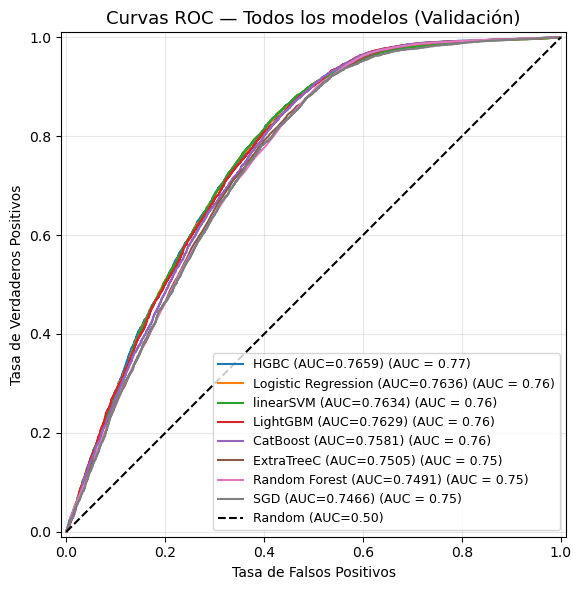

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

for r in sorted(resultados, key=lambda x: x['AUC-ROC'], reverse=True):
    RocCurveDisplay.from_predictions(
        y_val, r['_proba'],
        name=f"{r['Modelo']} (AUC={r['AUC-ROC']})",
        ax=ax
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)')
ax.set_title('Curvas ROC — Todos los modelos (Validación)', fontsize=13)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparacion.png', dpi=150)
plt.show()

## 7. Matriz de confusión del mejor modelo

Mejor modelo: HGBC — AUC-ROC: 0.7659 | Gini: 0.5318


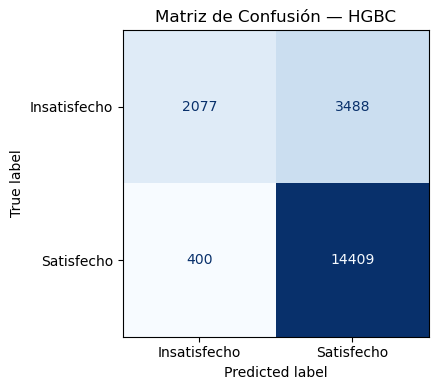

In [65]:
# Tomamos el modelo con mayor AUC-ROC
mejor = max(resultados, key=lambda x: x['AUC-ROC'])
print(f'Mejor modelo: {mejor["Modelo"]} — AUC-ROC: {mejor["AUC-ROC"]} | Gini: {mejor["Gini"]}')

pred_mejor = (mejor['_proba'] >= 0.5).astype(int)
cm = confusion_matrix(y_val, pred_mejor)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Insatisfecho', 'Satisfecho'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {mejor["Modelo"]}', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_mejor.png', dpi=150)
plt.show()

## 8. Importancia de features del mejor modelo

Si el mejor modelo tiene `feature_importances_` (árboles) lo mostramos. Si es Logistic Regression usamos los coeficientes.

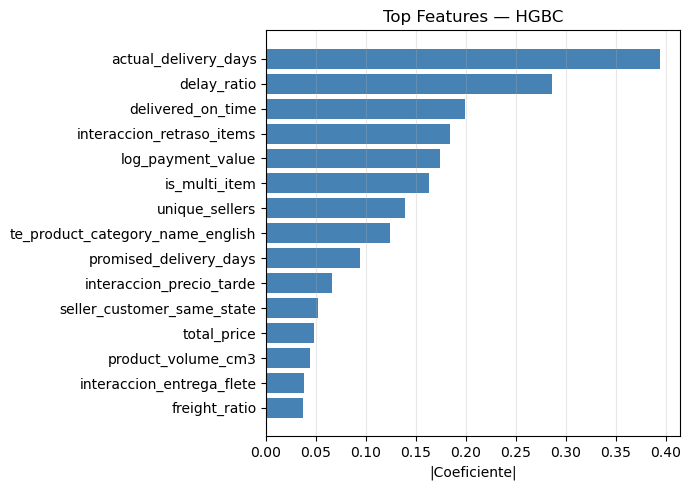

In [ ]:
mejor_aux = resultados[0] 
modelo_obj = mejor_aux['_modelo']
features   = X_train.columns.tolist()

if hasattr(modelo_obj, 'feature_importances_'):
    importancias = modelo_obj.feature_importances_
    label = 'Importancia (gain)'
elif hasattr(modelo_obj, 'coef_'):
    importancias = np.abs(modelo_obj.coef_[0])
    label = '|Coeficiente|'
else:
    importancias = None

if importancias is not None:
    df_imp = pd.DataFrame({'Feature': features, 'Importancia': importancias})
    df_imp = df_imp.sort_values('Importancia', ascending=True).tail(15)  # top 15

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(df_imp['Feature'], df_imp['Importancia'], color='steelblue')
    ax.set_xlabel(label)
    ax.set_title(f'Top Features — {mejor["Modelo"]}', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance_mejor.png', dpi=150)
    plt.show()
else:
    print('Este modelo no expone importancias directamente.')

### Análisis de umbral — todos los modelos

Con clase mayoritaria ~79%, el umbral 0.5 está sesgado hacia predecir siempre positivo.
Buscamos el umbral que maximiza F1 en validación para cada modelo, y comparamos cómo cambian las métricas.

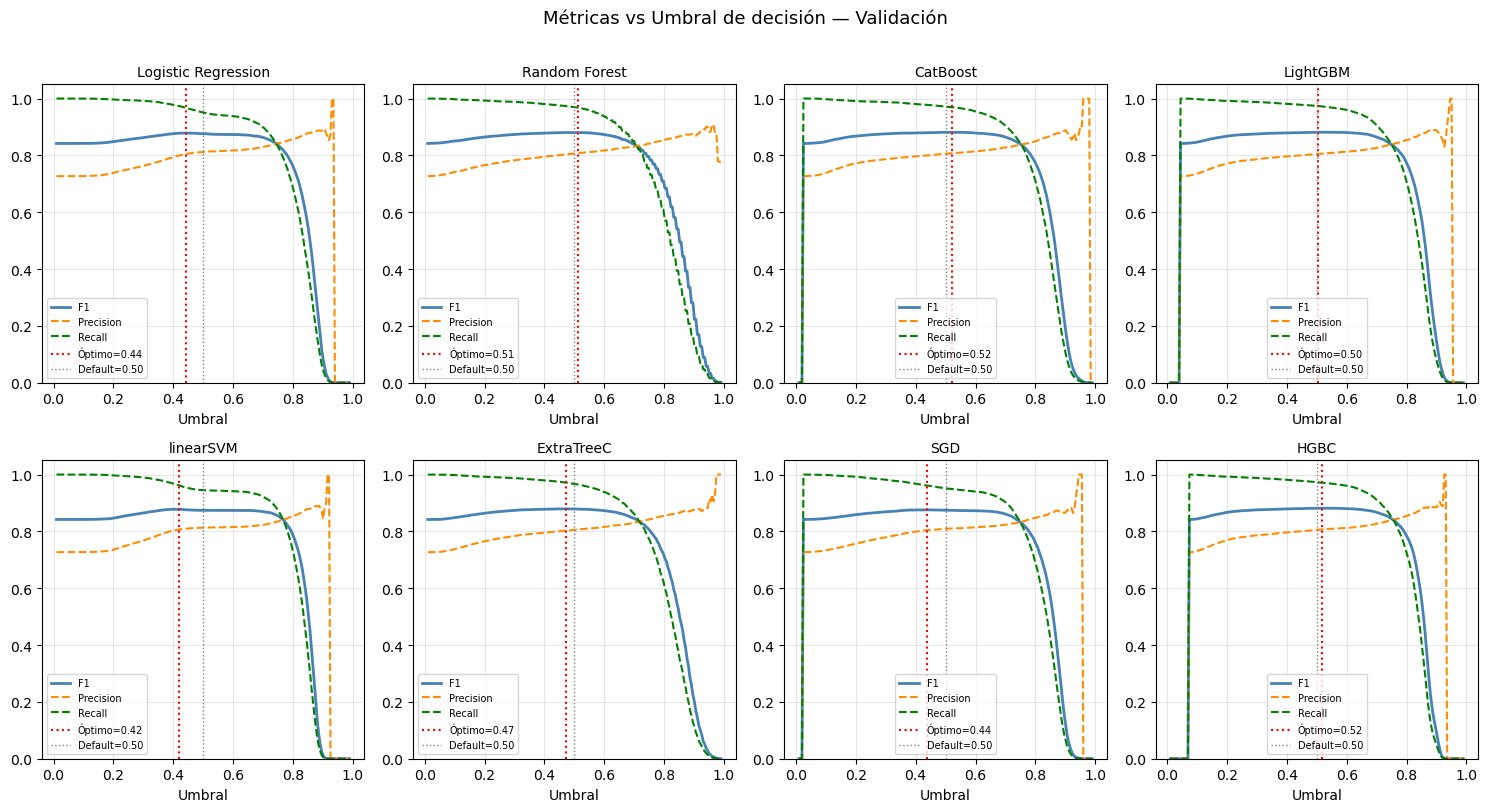

In [61]:
from sklearn.metrics import precision_recall_curve

umbrales_optimos = []

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, r in enumerate(resultados):
    proba = r['_proba']
    nombre = r['Modelo']

    # Barrido de umbrales
    thresholds = np.linspace(0.01, 0.99, 200)
    f1s, precs, recs = [], [], []

    for t in thresholds:
        pred_t = (proba >= t).astype(int)
        # Evitar división por cero si un umbral extremo produce solo una clase
        if pred_t.sum() == 0 or pred_t.sum() == len(pred_t):
            f1s.append(0); precs.append(0); recs.append(0)
            continue
        f1s.append(f1_score(y_val, pred_t, zero_division=0))
        precs.append(precision_score(y_val, pred_t, zero_division=0))
        recs.append(recall_score(y_val, pred_t, zero_division=0))

    # Umbral óptimo = el que maximiza F1
    idx_opt = np.argmax(f1s)
    t_opt   = thresholds[idx_opt]
    f1_opt  = f1s[idx_opt]
    prec_opt = precs[idx_opt]
    rec_opt  = recs[idx_opt]

    umbrales_optimos.append({
        'Modelo'       : nombre,
        'AUC-ROC'      : r['AUC-ROC'],
        'Umbral 0.5'   : r['F1'],
        'Umbral óptimo': round(t_opt, 3),
        'F1 óptimo'    : round(f1_opt, 4),
        'Precision'    : round(prec_opt, 4),
        'Recall'       : round(rec_opt, 4),
        'ΔF1'          : round(f1_opt - r['F1'], 4),
    })

    # Gráfico por modelo
    ax = axes[i]
    ax.plot(thresholds, f1s,   label='F1',        color='steelblue', lw=2)
    ax.plot(thresholds, precs, label='Precision',  color='darkorange', lw=1.5, ls='--')
    ax.plot(thresholds, recs,  label='Recall',     color='green',      lw=1.5, ls='--')
    ax.axvline(t_opt, color='red', ls=':', lw=1.5, label=f'Óptimo={t_opt:.2f}')
    ax.axvline(0.5,   color='gray', ls=':', lw=1,  label='Default=0.50')
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Umbral')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Ocultar subplot sobrante si hay número impar de modelos
for j in range(len(resultados), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Métricas vs Umbral de decisión — Validación', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('analisis_umbral.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
# Tabla comparativa: umbral 0.5 vs umbral óptimo
df_umbrales = pd.DataFrame(umbrales_optimos).sort_values('AUC-ROC', ascending=False)

def highlight_delta(s):
    if s.name == 'ΔF1':
        return ['color: green; font-weight: bold' if v > 0 else '' for v in s]
    return ['' for _ in s]

print('Comparación F1 con umbral 0.5 (default) vs umbral óptimo por F1:')
df_umbrales.style \
    .apply(highlight_delta) \
    .set_caption('ΔF1 = ganancia al usar umbral óptimo en lugar de 0.5')

Comparación F1 con umbral 0.5 (default) vs umbral óptimo por F1:


,Modelo,AUC-ROC,Umbral 0.5,Umbral óptimo,F1 óptimo,Precision,Recall,ΔF1
7,HGBC,0.765900,0.881100,0.517000,0.881600,0.807200,0.971200,0.000500
0,Logistic Regression,0.763600,0.876200,0.443000,0.878600,0.804900,0.967200,0.002400
4,linearSVM,0.763400,0.874200,0.419000,0.877800,0.806700,0.962600,0.003600
3,LightGBM,0.762900,0.881400,0.502000,0.881700,0.805400,0.974000,0.000300
2,CatBoost,0.758100,0.880900,0.522000,0.881200,0.807700,0.969500,0.000300
5,ExtraTreeC,0.750500,0.879000,0.473000,0.879300,0.803200,0.971400,0.000300
1,Random Forest,0.749100,0.880500,0.512000,0.880700,0.808200,0.967400,0.000200
6,SGD,0.746600,0.874600,0.438000,0.876000,0.804400,0.961600,0.001400


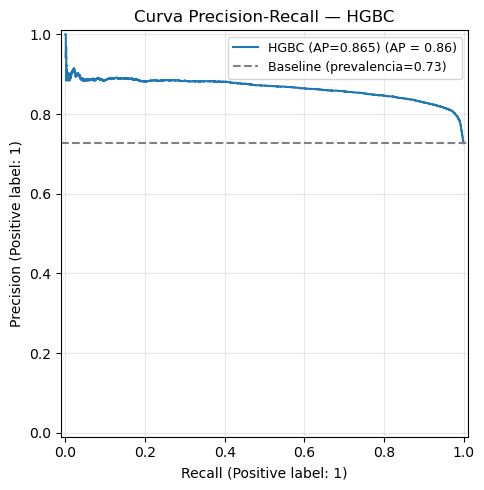


Average Precision (AP): 0.8649
AP = área bajo la curva Precision-Recall. Más informativo que AUC cuando hay desbalance.


In [70]:
# Curva Precision-Recall del mejor modelo (complementa la ROC)
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

mejor_r = max(resultados, key=lambda x: x['AUC-ROC'])
ap = average_precision_score(y_val, mejor_r['_proba'])

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_val, mejor_r['_proba'],
    name=f"{mejor_r['Modelo']} (AP={ap:.3f})",
    ax=ax
)

# Línea de base = prevalencia de la clase positiva
prevalencia = y_val.mean()
ax.axhline(prevalencia.item(), color='gray', ls='--', label=f'Baseline (prevalencia={prevalencia.item():.2f})')
ax.set_title(f'Curva Precision-Recall — {mejor_r["Modelo"]}', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_mejor.png', dpi=150)
plt.show()

print(f'\nAverage Precision (AP): {ap:.4f}')
print('AP = área bajo la curva Precision-Recall. Más informativo que AUC cuando hay desbalance.')

## 9. Resumen y decisión

Corre esta celda después de revisar los resultados para registrar tu elección.

In [71]:
print('=' * 50)
print('RESUMEN STAGE 3 — BASELINE MULTIMODELO')
print('=' * 50)
print(df_res.to_string(index=False))
print()
print(f'→ Modelo seleccionado para Optuna: {mejor["Modelo"]}')
print(f'  AUC-ROC val : {mejor["AUC-ROC"]}')
print(f'  Gini val    : {mejor["Gini"]}')
print(f'  F1 val      : {mejor["F1"]}')
print()
print('PRÓXIMO PASO: Hiperparametrización con Optuna')
print()
print('NOTA: Usar el umbral óptimo del análisis anterior al evaluar en test, no 0.5.')

RESUMEN STAGE 3 — BASELINE MULTIMODELO
             Modelo  AUC-ROC   Gini     F1  Precision  Recall  Brier↓
               HGBC   0.7659 0.5318 0.8811     0.8051  0.9730  0.1469
Logistic Regression   0.7636 0.5271 0.8762     0.8124  0.9509  0.1504
          linearSVM   0.7634 0.5268 0.8742     0.8131  0.9452  0.1510
           LightGBM   0.7629 0.5258 0.8814     0.8047  0.9743  0.1471
           CatBoost   0.7581 0.5163 0.8809     0.8057  0.9715  0.1476
         ExtraTreeC   0.7505 0.5011 0.8790     0.8054  0.9672  0.1502
      Random Forest   0.7491 0.4983 0.8805     0.8058  0.9704  0.1502
                SGD   0.7466 0.4933 0.8746     0.8091  0.9515  0.1527

→ Modelo seleccionado para Optuna: HGBC
  AUC-ROC val : 0.7659
  Gini val    : 0.5318
  F1 val      : 0.8811

PRÓXIMO PASO: Hiperparametrización con Optuna

NOTA: Usar el umbral óptimo del análisis anterior al evaluar en test, no 0.5.
